# Risk Classification Model

Scores the 280,284 contracts the rule engine defers — everything not already unscoreable,
exceptional, or escalated because a control could not be evaluated.

## The label is defined, not observed

This extract contains **no realised outcome** — no fraud, dispute, cancellation or audit finding
anywhere in its 21 columns. So there is nothing to predict in the ordinary sense. The label has to be defined by rule instead:

> a contract is **high attention** when its amount is in the top quartile of contracts within the
> same procurement category and region, **and** the procurement method is non-competitive.

Defining a proxy label this way is the normal thing to do when none exists. Two consequences follow,
and both belong in any honest reading of the numbers below:

1. **Any score measures agreement with a definition, never with reality.** The definition encodes an
   assumption — that large and non-competitive means risky — which nothing in this data verifies.
2. **Both halves of the definition are columns we already hold**, so a model handed those columns
   scores a perfect AUC. That is target leakage, and the fix is to withhold them.

In [1]:
import sys, warnings, pickle
from pathlib import Path
# Resolve the repo root by walking up until the package is found, rather than
# assuming the kernel's working directory is notebooks/. Opening this notebook
# from the repo root would otherwise fail on this very first line.
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "src" / "procurement_risk").exists())
sys.path.insert(0, str(REPO / "src"))
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option("display.width", 210); pd.set_option("display.max_columns", 40)

from procurement_risk import config, model as M

eligible = pd.read_parquet(config.DATA_DIR / "model_eligible.parquet")
splits = M.split_by_fiscal_year(eligible)
y_all = M.build_target(eligible)
print(f"model-eligible contracts : {len(eligible):,}")
print(f"high attention (label=1) : {int(y_all.sum()):,}  ({y_all.mean()*100:.2f}%)")

model-eligible contracts : 280,284
high attention (label=1) : 10,281  (3.67%)


## 1. Why this definition is a reasonable one

The definition deserves a defence as well as a critique. Absent any outcome data, it is a well-chosen proxy:

**It isolates exposure that no market test has checked.** The two conditions together pick out
contracts where a large sum was committed on a decision no competitor challenged. That is precisely
the combination a procurement control function worries about — concentrated spend with no
independent price discovery behind it.

**Neither condition alone would work, and the conjunction is the insight.** Large-but-competitive is
ordinary: major infrastructure is *supposed* to be expensive, and competition supplies the price
check. Small-but-non-competitive is also ordinary and cheap to get wrong: direct-selecting a $5,000
consultant is routine and the exposure is trivial. Only together do they describe something worth a
senior reviewer's time.

**It is peer-relative rather than absolute.** "Top quartile within the same category and region"
compares a Latin American consultancy against Latin American consultancies, not against South Asian
road works. An absolute dollar threshold would simply relabel the definition "is this a Works
contract", which carries no information a reviewer does not already have.

**It is observable when the decision has to be made.** Both halves are known at signing — and, being
properties of the award itself rather than of its consequences, at submission too. A label that
required waiting for an outcome would be useless for prior review, whatever its statistical merits.

**It is auditable.** A borrower can be told exactly why their contract was routed for closer review,
in one sentence, with the threshold named. That matters more for a fiduciary control than a marginal
gain in predictive accuracy would.

It also mirrors how the Bank already works: prior-review thresholds are themselves a function of
contract value and procurement method, so the definition encodes existing policy rather than
inventing a new theory of risk.

**What it is not** is a measure of wrongdoing. It flags *structural* exposure, not misconduct — most
of the contracts it selects will be perfectly proper, and some genuinely problematic contracts will
be small, competitive, and invisible to it. Section 7 sets out the limitations in full.

## 2. Leakage — measured, not asserted

Train with the label's own inputs present and both models return a **perfect AUC of 1.0000** on
held-out years. That is not skill. It is the definition being read back.

In [2]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
tr, va = splits["train"], splits["validate"]
ytr, yva = M.build_target(tr), M.build_target(va)

def quick_auc(cols):
    Xtr = M.build_design_matrix(tr, cols)
    Xva = M.align_columns(M.build_design_matrix(va, cols), Xtr.columns)
    g = HistGradientBoostingClassifier(max_iter=60, random_state=0).fit(Xtr, ytr)
    return roc_auc_score(yva, g.predict_proba(Xva)[:, 1])

print(f"WITH the label's own inputs : AUC {quick_auc(M.feature_columns(True)):.4f}   <- tautology")
print(f"WITHOUT them                : AUC {quick_auc(M.feature_columns()):.4f}   <- the model that ships")
print("\nwithheld:", list(M.LABEL_DEFINING_FEATURES))

WITH the label's own inputs : AUC 1.0000   <- tautology


WITHOUT them                : AUC 0.8601   <- the model that ships

withheld: ['amount_percentile_in_category_region', 'is_competitive_method', 'amount_vs_category_region_median', 'amount_usd', 'log_amount']


### 2.1 Two more leaks, found by measuring

Dropping the two columns the label names is not enough. Two others give the answer away as well.

**`amount_vs_practice_median`** is the amount compared against a *different* peer grouping — the
sector rather than the category and region. On its own it scores **0.81 AUC**, and it correlates
**0.83** with the category-and-region percentile. It is the amount in disguise.

The general rule: any feature comparing an amount to a benchmark rebuilds the label's first
condition.

**`supplier_is_known`** is worse, because it decides the label on its own.

The placeholder supplier only ever appears on Individual Consultant Selection, and that method is
competitive. So those contracts can never meet the label's second condition. Every one of them is
routine — guaranteed, before the model looks at anything. That is **62,992 contracts, 22.5% of the
population**.

Being guaranteed routine is not itself a problem. It is simply true, and a reviewer would want to
know it.

**The problem is what it does to the score.** The model can spot those records instantly — their
supplier history is missing — and mark them routine. That is a fifth of the test set answered for
free, and it flatters every average:

| | AUC on the test years |
|---|---|
| All records | **0.845** |
| Records that could genuinely go either way | **0.799** |

Dropping the flag does not help. `supplier_prior_contract_count` is missing on exactly those rows,
and a tree can split on missingness instead.

So no feature selection fixes this. It is the label definition meeting a property of the data. What
it changes is **reporting**: every headline figure is quoted on both populations, so the easy 22.5%
never passes for skill.

In [3]:
forced = M.structurally_negative(eligible)
print(f"records that CANNOT be positive : {int(forced.sum()):,}  ({forced.mean()*100:.1f}%)")
print(f"  their label rate               : {float(y_all[forced].mean()):.4f}  (zero, by construction)")
print(f"  their procurement method       : {eligible.loc[forced,'procurement_method_raw'].unique().tolist()}")

records that CANNOT be positive : 62,992  (22.5%)
  their label rate               : 0.0000  (zero, by construction)
  their procurement method       : ['Individual Consultant Selection']


## 3. Training

A logistic-regression baseline and a gradient-boosted tree. Fitted on FY2020–22, probabilities calibrated on FY2023, tested once
on FY2024–26. FY2027 is quarantined — a seven-week stub where testing would measure reporting lag
rather than skill.

Calibration uses **Platt scaling rather than isotonic**. Isotonic calibrates marginally better here
(2.8pp vs 5.3pp maximum deviation) but collapses 51,783 distinct scores into 107 steps, which
flattens the threshold curve into unusable plateaus. A risk score has to rank as well as calibrate.

In [4]:
for name, part in splits.items():
    yy = M.build_target(part)
    print(f"  {name:<12} FY{sorted(part.fiscal_year.unique())}  n={len(part):>7,}  "
          f"positives={int(yy.sum()):>5,} ({yy.mean()*100:.2f}%)")

  train        FY[np.int64(2020), np.int64(2021), np.int64(2022)]  n=115,957  positives=4,830 (4.17%)
  validate     FY[np.int64(2023)]  n= 42,950  positives=1,383 (3.22%)
  test         FY[np.int64(2024), np.int64(2025), np.int64(2026)]  n=120,238  positives=3,995 (3.32%)
  quarantined  FY[np.int64(2027)]  n=  1,139  positives=   73 (6.41%)


In [5]:
gbt = M.train(splits["train"], splits["validate"], kind="gbt")
lr  = M.train(splits["train"], splits["validate"], kind="logistic")
for m in (gbt, lr):
    p = m.predict_proba(splits["validate"])
    m.threshold  = M.choose_threshold(yva, p, min_recall=0.90)
    m.band_edges = M.choose_band_edges(p)
gbt = M.attach_explainer(gbt, splits["train"].head(2000))
print(f"features {len(M.feature_columns())} -> design columns {len(gbt.columns)}")
print("features:", M.feature_columns())

features 12 -> design columns 23
features: ['supplier_prior_contract_count', 'project_contract_sequence', 'days_into_fiscal_year', 'fy_quarter', 'consortium_size', 'benchmark_support_n', 'supplier_is_domestic', 'is_first_contract_in_project', 'supplier_in_secrecy_jurisdiction', 'region', 'procurement_category', 'review_type']


## 4. Evaluation — calibration, top-decile precision, and hit rate

**Calibration.** **Precision in the top decile.** **The share of flagged contracts that really are
high attention.**

Each is reported for both models, on validation and on test. The quarantined FY2027 stub is shown
separately.

There is also a fourth row per model: the population that *can* be positive. The 22.5% of records
that are guaranteed negatives inflate every aggregate figure, so both versions are shown.

In [6]:
rows = []
for nm, m in (("GBT", gbt), ("LogReg", lr)):
    for s in ("validate", "test", "quarantined"):
        r = M.evaluate(m, splits[s]); r.update(model=nm, split=s); rows.append(r)
    sub = splits["test"][~M.structurally_negative(splits["test"])]
    r = M.evaluate(m, sub); r.update(model=nm, split="test (can be positive)"); rows.append(r)
pd.DataFrame(rows)[["model","split","n","base_rate","auc","brier",
                    "precision_at_top_decile","share_flagged_in_target","flagged_share_of_population"]]

,model,split,n,base_rate,auc,brier,precision_at_top_decile,share_flagged_in_target,flagged_share_of_population
0,GBT,validate,42950,0.0322,0.8558,0.02806,0.1593,0.0726,0.4000
1,GBT,test,120238,0.0332,0.8445,0.02945,0.1501,0.0812,0.3518
2,GBT,quarantined,1139,0.0641,0.7882,0.05479,0.2212,0.1263,0.4381
3,GBT,test (can be positive),94051,0.0425,0.7993,0.03766,0.1657,0.0812,0.4498
4,LogReg,validate,42950,0.0322,0.8329,0.02959,0.1364,0.0610,0.5000
5,LogReg,test,120238,0.0332,0.8150,0.03378,0.1273,0.0704,0.4004
6,LogReg,quarantined,1139,0.0641,0.8316,0.05700,0.2124,0.1477,0.3863
7,LogReg,test (can be positive),94051,0.0425,0.7612,0.04319,0.1279,0.0704,0.5118


Reading this: the gradient-boosted model reaches **AUC 0.845 on test**, falling to **0.799** on the
population that can actually be positive — the gap is the free negatives. Precision in the top decile
is **0.150 against a 0.033 base rate**, a **4.5× lift**, which is the most defensible single statement
about what the model is worth. Logistic regression trails it consistently but not enormously.

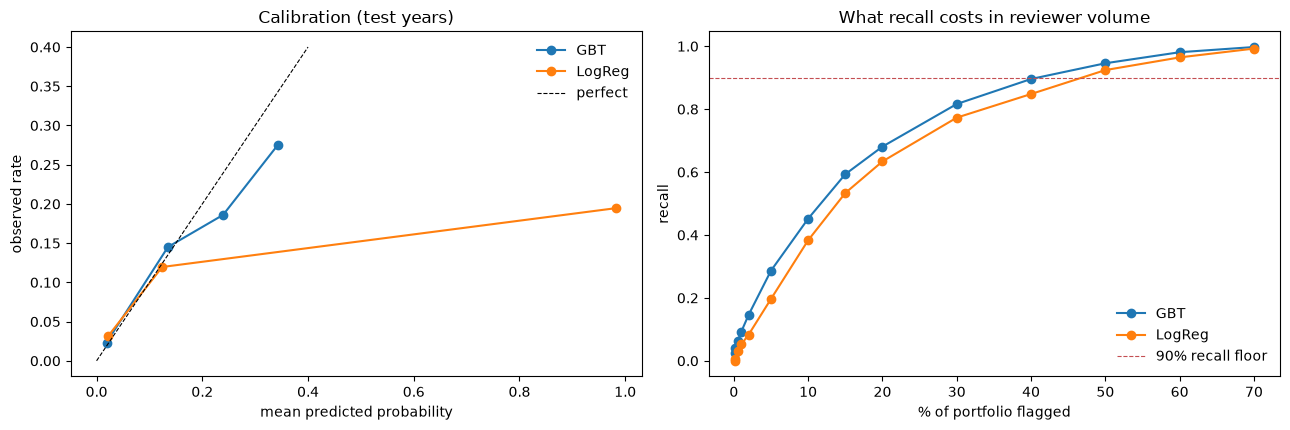

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for nm, m in (("GBT", gbt), ("LogReg", lr)):
    yte = M.build_target(splits["test"]); p = m.predict_proba(splits["test"])
    t = M.calibration_table(yte, p); t = t[t.n > 200]
    axes[0].plot(t.mean_predicted, t.observed_rate, "o-", label=f"{nm}")
    tbl = M.threshold_table(yte, p)
    axes[1].plot(tbl["flagged_%"], tbl.recall, "o-", label=nm)
axes[0].plot([0, .4], [0, .4], "k--", lw=.8, label="perfect")
axes[0].set(xlabel="mean predicted probability", ylabel="observed rate", title="Calibration (test years)")
axes[0].legend(frameon=False)
axes[1].axhline(0.90, color="#C44E52", ls="--", lw=.8, label="90% recall floor")
axes[1].set(xlabel="% of portfolio flagged", ylabel="recall", title="What recall costs in reviewer volume")
axes[1].legend(frameon=False)
plt.tight_layout(); plt.show()

## 5. Threshold — chosen conservatively, and what that costs

Missing a genuinely high-attention contract carries more risk than
over-flagging a routine one.* So **recall is the constraint and reviewer volume is the price**. The
threshold is the tightest cut-off on the **validation year alone** that still catches 90% of
high-attention contracts, then applied unchanged to test.

The table below is the justification. It also carries an uncomfortable finding worth stating plainly:
**at 90% recall the model flags 40% of the validation year at 7.3% precision** (35% of the test
years). That is what conservatism costs with a model this strong, and it is the evidence for the
conclusion in section 6 — this model should not be a standalone gate.

In [8]:
M.threshold_table(yva, gbt.predict_proba(splits["validate"]))

,flag_rate_target,threshold,flagged,flagged_%,recall,precision
0,0.001,0.700056,43,0.10,0.0275,0.8837
1,0.002,0.578794,94,0.22,0.0513,0.7553
2,0.005,0.364014,215,0.50,0.0687,0.4419
3,0.010,0.267594,430,1.00,0.1135,0.3651
4,0.020,0.191136,859,2.00,0.1706,0.2747
5,0.050,0.121750,2149,5.00,0.3254,0.2094
6,0.100,0.080964,4297,10.00,0.4946,0.1592
7,0.150,0.062203,6446,15.01,0.6226,0.1336
8,0.200,0.047461,8593,20.01,0.7137,0.1149
9,0.300,0.031808,12885,30.00,0.8221,0.0882


In [9]:
print(f"chosen threshold (GBT) : {gbt.threshold:.6f}   [tightest cut-off with >=90% recall on FY2023]")
print(f"risk bands             : LOW < {gbt.band_edges[0]:.4f} <= MEDIUM < {gbt.band_edges[1]:.4f} <= HIGH")
te = splits["test"]; p = gbt.predict_proba(te)
bands = pd.Series([gbt.band(s) for s in p]).value_counts()
out = pd.DataFrame({"contracts": bands})
out["% of test"] = (out.contracts / len(te) * 100).round(2)
out["high-attention rate"] = [float(M.build_target(te)[[gbt.band(s)==b for s in p]].mean()) for b in out.index]
out.round(4)

chosen threshold (GBT) : 0.022248   [tightest cut-off with >=90% recall on FY2023]
risk bands             : LOW < 0.0318 <= MEDIUM < 0.0810 <= HIGH


,contracts,% of test,high-attention rate
LOW,88661,73.74,0.0112
MEDIUM,19848,16.51,0.0617
HIGH,11729,9.75,0.1513


## 6. Per-record output

Risk score, band, and the three features moving it most — via SHAP on the tree model, so the
explanation comes from the model doing the scoring rather than a stand-in.

In [10]:
import json
scores = gbt.predict_proba(te)
for label, rec in (("HIGHEST-SCORING CONTRACT", te.iloc[[int(scores.argmax())]]),
                   ("A MID-BAND CONTRACT",      te.iloc[[int(np.argsort(scores)[len(scores)//2])]])):
    print(f"=== {label} ===")
    print(json.dumps(M.score_record(gbt, rec), indent=2)); print()

=== HIGHEST-SCORING CONTRACT ===
{
  "risk_score": 0.8529,
  "risk_band": "HIGH",
  "top_features": [
    {
      "feature": "supplier_prior_contract_count",
      "value": 61.0,
      "contribution": 4.71368,
      "direction": "increases risk"
    },
    {
      "feature": "procurement_category_Works",
      "value": 0.0,
      "contribution": 0.86261,
      "direction": "increases risk"
    },
    {
      "feature": "supplier_is_domestic",
      "value": 0.0,
      "contribution": 0.82792,
      "direction": "increases risk"
    }
  ],
  "model_version": "v1.0",
  "threshold": 0.022248
}

=== A MID-BAND CONTRACT ===
{
  "risk_score": 0.0125,
  "risk_band": "LOW",
  "top_features": [
    {
      "feature": "supplier_prior_contract_count",
      "value": 1.0,
      "contribution": 1.66011,
      "direction": "increases risk"
    },
    {
      "feature": "project_contract_sequence",
      "value": 168.0,
      "contribution": -0.59747,
      "direction": "decreases risk"
    },
    {


## 7. What this model is actually for — and its limitations

**It is not a predictor of risk.** It is a predictor of a definition, and the definition is an
assumption. Every number above measures agreement with that assumption.

**The rule engine already does the deterministic part.** Since the label is fully computable from two
columns, a production system would simply apply the rule rather than model it. What the model adds is
a **graded contextual score** over the records the rules clear — useful for ranking the routine
population for periodic sampling, and for records where the peer-group percentile is unknown.

**It should not be a standalone gate.** At a conservative threshold it flags 40% of the portfolio to reach 90% recall. The band is the more useful output: `LOW` / `MEDIUM` /
`HIGH` carry high-attention rates of **1.1% / 6.2% / 15.1%** on the test years — a 13x gradient that
supports prioritising a review queue, which a binary flag at this precision does not.

### Stated limitations

- **No ground truth exists.** No fraud, dispute or cancellation label anywhere in the extract. The
  target is a definition; performance against it cannot establish real-world precision.
- **22.5% of the population is a guaranteed negative** by construction, and it is not a random 22.5%
  — it is entirely individual-consultant awards. Aggregate metrics are inflated accordingly, which is
  why both populations are reported.
- **The label inherits every feature-preparation caveat**, including that the peer-group percentile is unavailable
  for 2,706 warm-up records, which the rule engine routes to a human rather than the model.
- **Performance degrades across time** — AUC 0.856 on FY2023, 0.845 on FY2024–26 — consistent with a
  portfolio that shifts. A deployed version would need scheduled retraining and drift monitoring.
- **Logistic regression is not a fair baseline for missingness.** It cannot take NaN, so it receives
  median imputation plus a missingness indicator, while the tree model uses NaN natively. Part of the
  gap between them is that handling, not model capacity.